In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
from plotnine import *

titanic = sns.load_dataset('titanic')

-----

# Dtypes

In [10]:
users_dt = pd.read_csv('../Datasets/Exercise2_datasets/BX-Users.csv')
users_dt.dtypes

User-ID       int64
Location     object
Age         float64
dtype: object

-------

# How To Filter

use `.loc` instead of `titanic[~ind, 'age']`

In [4]:
ind = np.isnan(titanic['age'])
titanic.loc[~ind, 'age'].values.mean()

np.float64(29.69911764705882)

In [39]:
books_dt = pd.read_csv('../Datasets/Exercise2_datasets/BX-Books.csv') 
books_dt = books_dt.drop(columns = ['Image-URL-S', 'Image-URL-M', 'Image-URL-L']) # önemsiz

book_df_2 = books_dt[books_dt['Year-Of-Publication'].isin(range(1900,2020))]
book_df_2.head()

books_dt[books_dt['Year-Of-Publication'].isin(range(1900,2020))][['ISBN','Book-Title']]

,ISBN,Book-Title
0,0195153448,Classical Mythology
1,0002005018,Clara Callan
2,0060973129,Decision in Normandy
3,0374157065,Flu: The Story of the Great Influenza Pandemic...
4,0393045218,The Mummies of Urumchi
...,...,...
262495,0441297528,The Golden Naginata
262496,0441792642,Sensei II: Sword Master
262497,0448164884,More Stan Fishchler's Sports Stumpers
262498,0451520521,Babbitt


----

# idxmin - Argmin

In [5]:
tips = sns.load_dataset('tips')
tips['total_bill'].idxmin()

67

------

# Categories

* `nunique()` → how many values actually appear

* `dtype.categories` → how many values are allowed by the type

<u>return_counts = True</u>

In [8]:
b = tips['day']
unique_values, counts = np.unique(b, return_counts= True)

print('Values:', unique_values)
print('Counts:', counts)

b.dtype.categories

Values: ['Fri' 'Sat' 'Sun' 'Thur']
Counts: [19 87 76 62]


Index(['Thur', 'Fri', 'Sat', 'Sun'], dtype='object')

-------

# Drop 

## Column

In [16]:
books_dt = pd.read_csv('../Datasets/Exercise2_datasets/BX-Books.csv')

books_dt = books_dt.drop(columns = ['Image-URL-S', 'Image-URL-M', 'Image-URL-L'])

## NA

In [42]:
np.random.seed(0)

df = pd.DataFrame({
    'age': [23, np.nan, 35, np.nan, 42],
    'fare': [100, 200, np.nan, 150, np.nan],
    'sex': ['male', 'female', 'female', 'male', 'female']
})

df.head()

,age,fare,sex
0,23.0,100.0,male
1,NaN,200.0,female
2,35.0,NaN,female
3,NaN,150.0,male
4,42.0,NaN,female


In [43]:
df.dropna(subset = ['fare', 'age'], how = 'all')

,age,fare,sex
0,23.0,100.0,male
1,NaN,200.0,female
2,35.0,NaN,female
3,NaN,150.0,male
4,42.0,NaN,female


how = 'all' makes sure that only rows are dropped where both, fare and age are none

------

# Unique

In [21]:
books_dt = pd.read_csv('../Datasets/Exercise2_datasets/BX-Books.csv')

books_dt['Book-Author'].nunique()

98538

In [25]:
tips = sns.load_dataset('tips')

b = tips['time']
unique_values, counts = np.unique(b, return_counts= True)

print('Values:', unique_values)
print('Counts:', counts)

Values: ['Dinner' 'Lunch']
Counts: [176  68]


---------

# Common - mode

the most common rating value larger than 0

In [22]:
ratings_dt = pd.read_csv('../Datasets/Exercise2_datasets/BX-Book-Ratings.csv')

ratings_dt[ ratings_dt['Book-Rating'] != 0]['Book-Rating'].mode()

0    8
Name: Book-Rating, dtype: int64

-----

# Size 

size()

In [ ]:
star_wars_df = pd.read_csv('../Datasets/Exercise2_datasets/star_wars_character_dataset.csv',
                    usecols = ["name", "height", "mass", "birth_year", "sex", "homeworld", "species"])

star_wars_df = star_wars_df.rename(columns = {'birth_year': 'age'})

star_wars_df[star_wars_df['height'] > 200].groupby('species').size()

species
Gungan      2
Human       1
Kaleesh     1
Kaminoan    2
Pau'an      1
Quermian    1
Wookiee     2
dtype: int64

size

In [26]:
tips = sns.load_dataset('tips')

tips.size

1708

-------------

# Rename Column

In [27]:
star_wars_df = pd.read_csv('../Datasets/Exercise2_datasets/star_wars_character_dataset.csv',
                    usecols = ["name", "height", "mass", "birth_year", "sex", "homeworld", "species"])

star_wars_df = star_wars_df.rename(columns = {'birth_year': 'age'})
star_wars_df.head()

,name,height,mass,age,sex,homeworld,species
0,Luke Skywalker,172.0,77.0,19.0,male,Tatooine,Human
1,C-3PO,167.0,75.0,112.0,none,Tatooine,Droid
2,R2-D2,96.0,32.0,33.0,none,Naboo,Droid
3,Darth Vader,202.0,136.0,41.9,male,Tatooine,Human
4,Leia Organa,150.0,49.0,19.0,female,Alderaan,Human


------

# Transform

/var/folders/nn/rd9y9hfx7qz4tk9cjwqs2xrh0000gn/T/ipykernel_92911/873672501.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


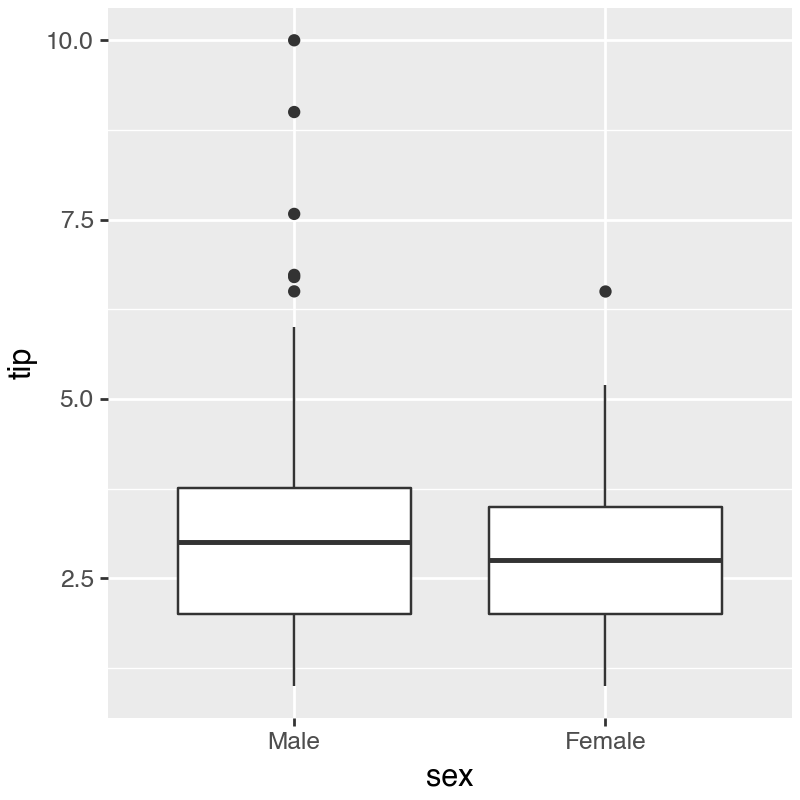

In [36]:
dt = sns.load_dataset('tips')
dt['sex_av'] = dt.groupby('sex')['tip'].transform('mean')

dt['dist_avg'] = dt['tip'] - dt['sex_av']

(
    ggplot(dt, aes('sex', 'tip')) + 
    geom_boxplot() +
    theme(figure_size= (4,4))
)

--------

# Union

concat 

In [45]:
import glob

files = glob.glob('../Datasets/Exercise2_datasets/extdata 3/baby-names/*.csv')

dfs = []

for i in range(len(files)):
    df = pd.read_csv(files[i])
    df['year'] = files[i].split('/')[-1].split('.')[0]
    dfs.append(df)

df = pd.concat(dfs, ignore_index= True)  ## Important part
df.head()

,name,percent,year
0,Jacob,0.016514,2000
1,Michael,0.015346,2000
2,Matthew,0.013695,2000
3,Joshua,0.013194,2000
4,Christopher,0.011990,2000
